In [1]:
from mastu import HSV
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget

In [2]:
shotn = 50501

In [3]:
import pyuda
client = pyuda.Client()

frame = HSV.getSingle(shotn, 500)[0]

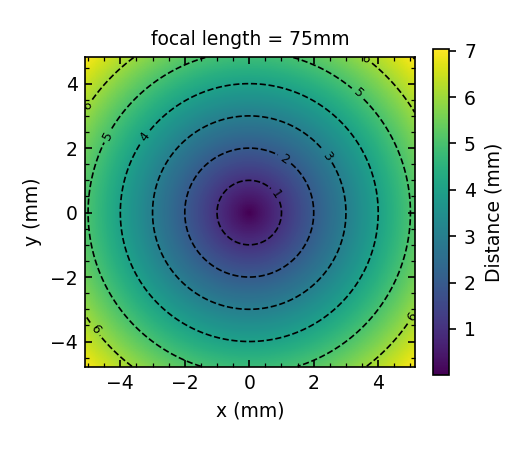

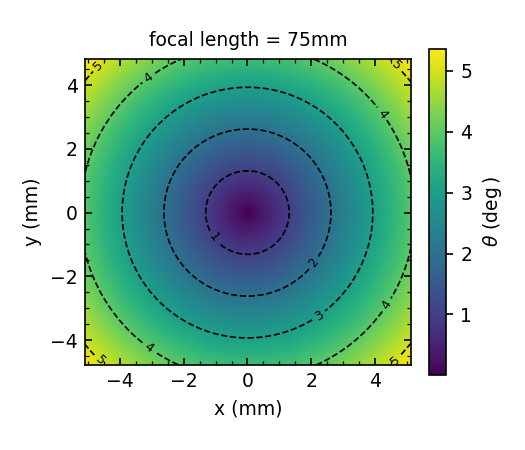

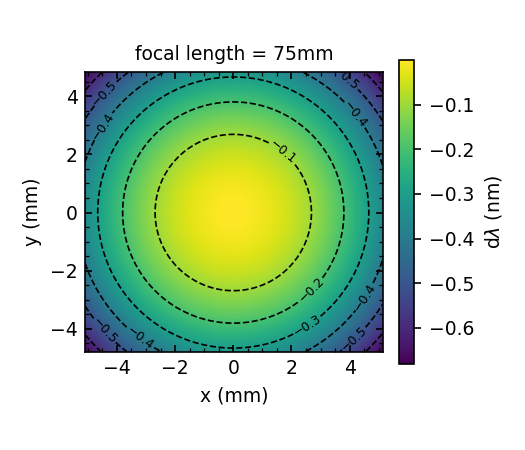

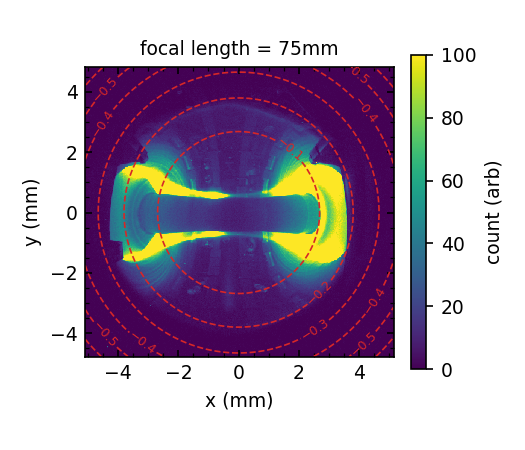

In [4]:
dx = 20e-6
nx = 1024
dy = 20e-6
ny = 1024
x0 = 0.
y0 = 0.

focalLength = 75e-3 # 75mm

wl0 = 656.1012e-9
n0 = 1.
n1 = 2.05

################################################################################

def calcShift(theta, wl0=656.1012, n0=1., n1=2.05):
    term1 = (n0 / n1)**2 * np.sin(theta)**2
    bracket = np.sqrt((1. - term1))
    return bracket * wl0

################################################################################

x = np.linspace(dx, nx*dx, nx)
x -= x.mean()
y = np.linspace(dy, ny*dy, ny)
y -= y.mean()
x, y = np.meshgrid(x, y)
xplot = HSV.transform(x, shotn) * 1e3
yplot = HSV.transform(y, shotn) * 1e3
distance = np.sqrt((x - x0)**2 + (y - y0)**2)
distanceplot = HSV.transform(distance, shotn) * 1e3

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, distanceplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Distance (mm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, distanceplot, np.arange(0., 7.1, 1.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

theta = np.arctan(distance / focalLength)
thetaplot = HSV.transform(np.rad2deg(theta), shotn)

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, thetaplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\theta$ ($\\deg$)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, thetaplot, np.arange(0., 5.1, 1.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

wavelength = calcShift(theta, wl0)
wavelengthplot = (HSV.transform(wavelength, shotn) - wl0) * 1e9

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, wavelengthplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\mathrm{d}\\lambda$ (nm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-1., 0., 0.1), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, frame, vmin=0, vmax=100)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('count (arb)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-1., 0., 0.1), 
    linestyles='--', linewidths=0.8, colors='C3'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

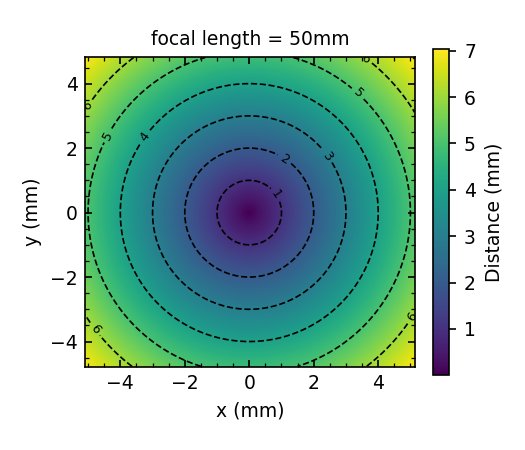

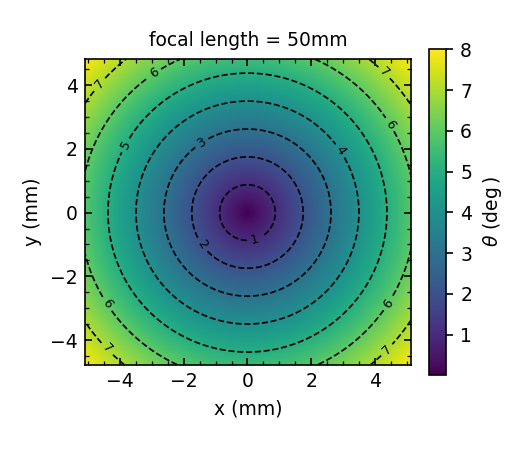

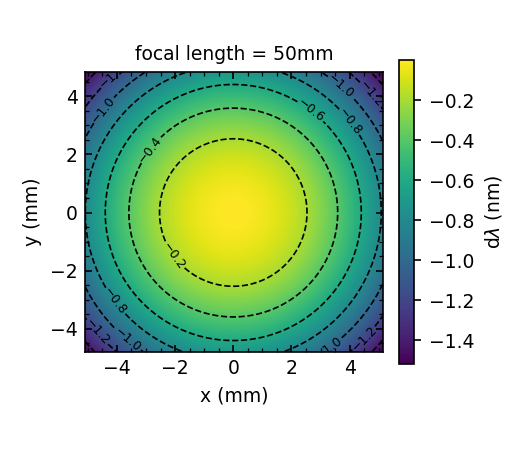

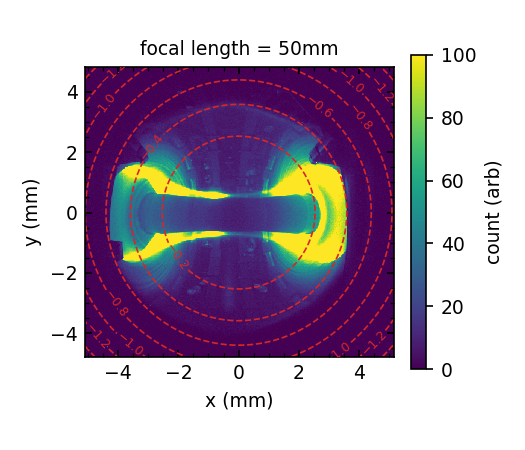

In [5]:
dx = 20e-6
nx = 1024
dy = 20e-6
ny = 1024
x0 = 0.
y0 = 0.

focalLength = 50e-3 # 75mm

wl0 = 656.1012e-9
n0 = 1.
n1 = 2.05

################################################################################

def calcShift(theta, wl0=656.1012, n0=1., n1=2.05):
    term1 = (n0 / n1)**2 * np.sin(theta)**2
    bracket = np.sqrt((1. - term1))
    return bracket * wl0

################################################################################

x = np.linspace(dx, nx*dx, nx)
x -= x.mean()
y = np.linspace(dy, ny*dy, ny)
y -= y.mean()
x, y = np.meshgrid(x, y)
xplot = HSV.transform(x, shotn) * 1e3
yplot = HSV.transform(y, shotn) * 1e3
distance = np.sqrt((x - x0)**2 + (y - y0)**2)
distanceplot = HSV.transform(distance, shotn) * 1e3

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, distanceplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Distance (mm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, distanceplot, np.arange(0., 7.1, 1.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

theta = np.arctan(distance / focalLength)
thetaplot = HSV.transform(np.rad2deg(theta), shotn)

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, thetaplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\theta$ ($\\deg$)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, thetaplot, np.arange(0., 9.1, 1.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

wavelength = calcShift(theta, wl0)
wavelengthplot = (HSV.transform(wavelength, shotn) - wl0) * 1e9

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, wavelengthplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\mathrm{d}\\lambda$ (nm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-1.6, 0., 0.2), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, frame, vmin=0, vmax=100)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('count (arb)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-1.6, 0., 0.2), 
    linestyles='--', linewidths=0.8, colors='C3'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

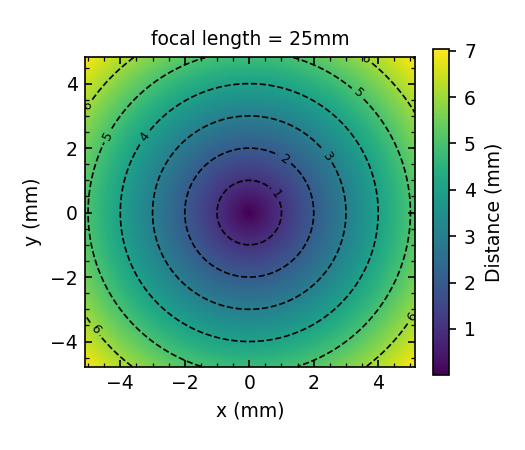

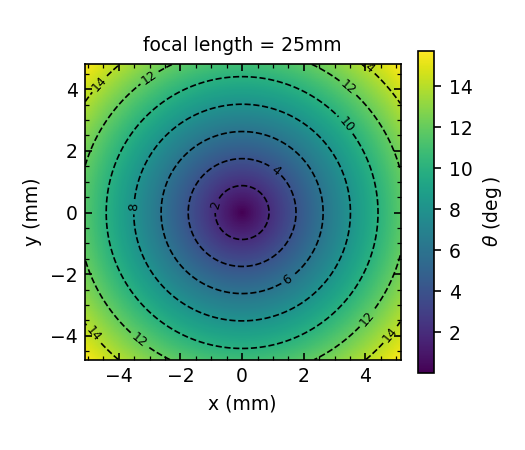

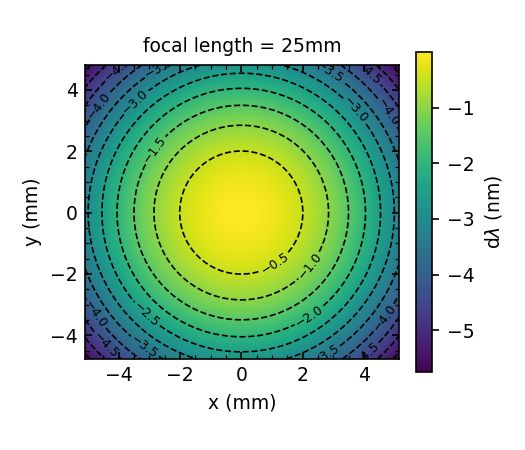

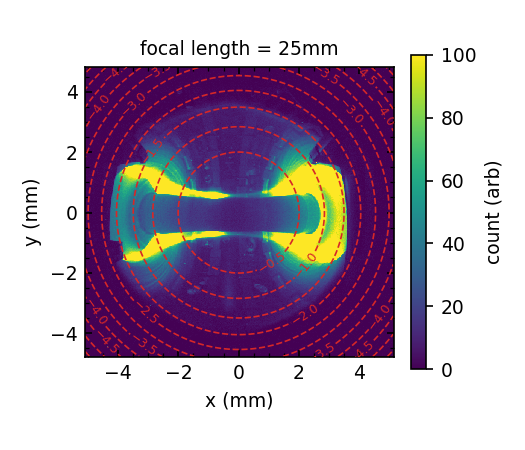

In [6]:
dx = 20e-6
nx = 1024
dy = 20e-6
ny = 1024
x0 = 0.
y0 = 0.

focalLength = 25e-3 # 75mm

wl0 = 656.1012e-9
n0 = 1.
n1 = 2.05

################################################################################

def calcShift(theta, wl0=656.1012, n0=1., n1=2.05):
    term1 = (n0 / n1)**2 * np.sin(theta)**2
    bracket = np.sqrt((1. - term1))
    return bracket * wl0

################################################################################

x = np.linspace(dx, nx*dx, nx)
x -= x.mean()
y = np.linspace(dy, ny*dy, ny)
y -= y.mean()
x, y = np.meshgrid(x, y)
xplot = HSV.transform(x, shotn) * 1e3
yplot = HSV.transform(y, shotn) * 1e3
distance = np.sqrt((x - x0)**2 + (y - y0)**2)
distanceplot = HSV.transform(distance, shotn) * 1e3

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, distanceplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('Distance (mm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, distanceplot, np.arange(0., 7.1, 1.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

theta = np.arctan(distance / focalLength)
thetaplot = HSV.transform(np.rad2deg(theta), shotn)

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, thetaplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\theta$ ($\\deg$)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, thetaplot, np.arange(0., 16.1, 2.), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

wavelength = calcShift(theta, wl0)
wavelengthplot = (HSV.transform(wavelength, shotn) - wl0) * 1e9

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, wavelengthplot)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$\\mathrm{d}\\lambda$ (nm)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-6., 0., 0.5), 
    linestyles='--', linewidths=0.8, colors='k'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()

################################################################################

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
pcm=ax.pcolormesh(xplot, yplot, frame, vmin=0, vmax=100)
cbar=fig.colorbar(pcm, ax=ax, fraction=0.046)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('count (arb)', fontsize=9)
ax.set_aspect('equal')
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.set_xticks(np.arange(-4., 4.1, 2))
ax.set_yticks(np.arange(-4., 4.1, 2))
ax.minorticks_on()
ax.set_xlabel('x (mm)', fontsize=9)
ax.set_ylabel('y (mm)', fontsize=9)
ax.set_title(f'focal length = {1e3*focalLength:.0f}mm', fontsize=9)
cnt=ax.contour(
    xplot, yplot, wavelengthplot, np.arange(-6, 0., 0.5), 
    linestyles='--', linewidths=0.8, colors='C3'
)
ax.clabel(cnt, inline=1, fontsize=6)
plt.tight_layout()